# heatmap trouble shooting

In [19]:
import pandas as pd
import numpy as np
from datetime import datetime
import time

from scipy.signal import find_peaks

import plotly.express as px

In [6]:
# load in data 

multi_right_df = pd.read_csv("multisurface differentiation/recordV2Primary.csv")
multi_left_df = pd.read_csv("multisurface differentiation/recordV2Secondary.csv")

In [7]:
# # clean & modify data 
# drop_columns = ['magn_x', 'magn_y', 'magn_z']

# multi_right_df = multi_right_df.drop(columns= drop_columns)
# multi_right_df

# multi_left_df = multi_left_df.drop(columns= drop_columns)
# # multi_left_df

In [8]:
multi_right_df["date_time"] = pd.to_datetime(multi_right_df['timestamp'], unit='ms')
multi_right_df["time_elapsed"] = (multi_right_df['date_time'] - multi_right_df['date_time'].iloc[0]).dt.total_seconds() * 100

multi_left_df["date_time"] = pd.to_datetime(multi_left_df['timestamp'], unit='ms')
multi_left_df["time_elapsed"] = ((multi_left_df['date_time'] - multi_left_df['date_time'].iloc[0]).dt.total_seconds())* 100

In [32]:
heel     = ['pressure_10', 'pressure_11', 'pressure_08']
midfoot  = ['pressure_03', 'pressure_07']
forefoot = ['pressure_02', 'pressure_05', 'pressure_04', 'pressure_06', 'pressure_09']
toes     = ['pressure_01', 'pressure_12']

sensor_cols = [*toes, *forefoot, *midfoot, *heel]
sensor_cols2 = [*heel, *midfoot, *forefoot, *toes]

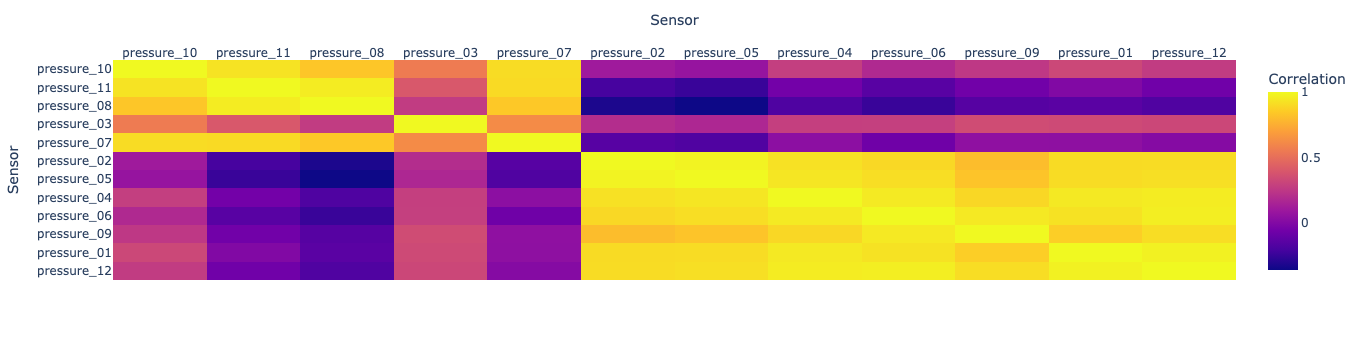

In [33]:
corr = multi_right_df[sensor_cols2].corr()

fig = px.imshow(
    corr.values,
    x=corr.columns,
    y=corr.index,
    labels=dict(x="Sensor", y="Sensor", color="Correlation"),
    aspect="auto",
)

fig.update_xaxes(side="top") 
fig.show() 

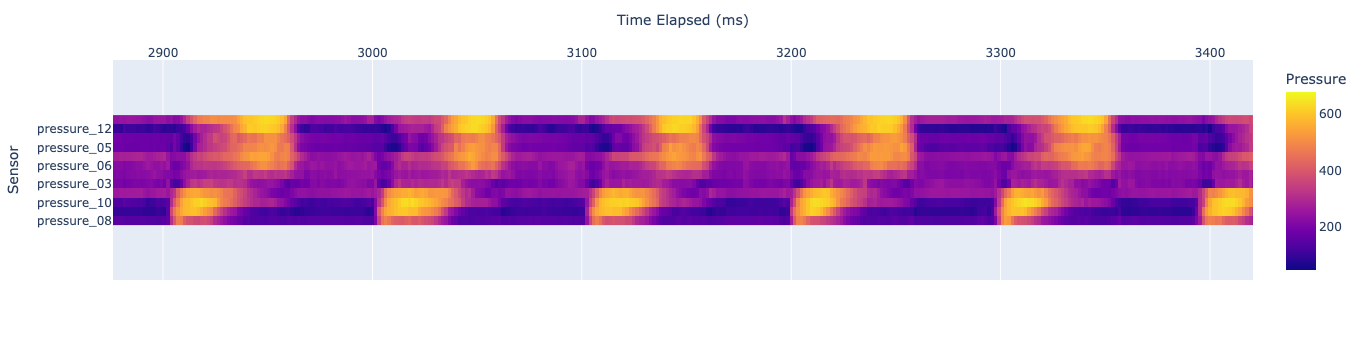

In [36]:
Z = multi_right_df[sensor_cols].T.values         # shape: (num_sensors, num_timepoints)
x = multi_right_df["time_elapsed"].values        # length: num_timepoints
y = sensor_cols                                  # length: num_sensors

fig = px.imshow(
    Z,
    x=x,
    y=y,
    aspect="auto",
    labels=dict(x="Time Elapsed (ms)", y="Sensor", color="Pressure"),
)

fig.update_xaxes(side="top")
fig.show()


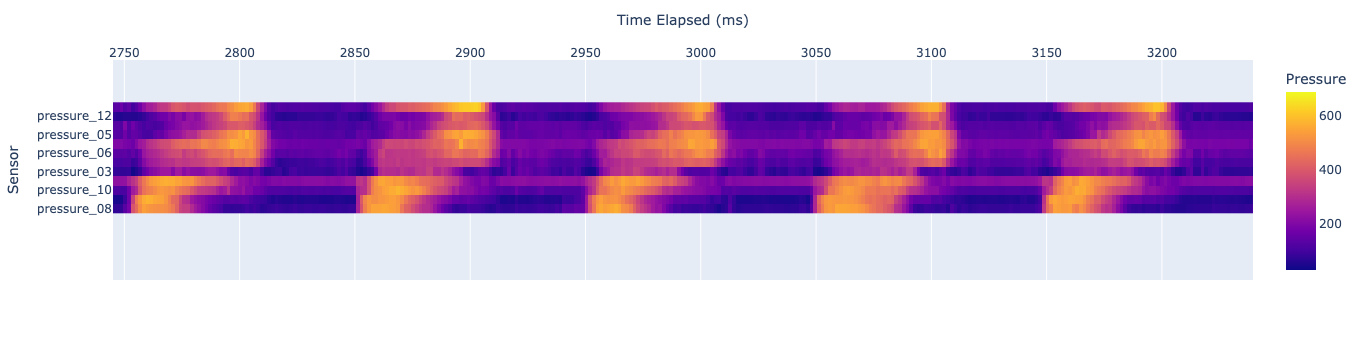

In [31]:
Z = multi_left_df[sensor_cols].T.values         # shape: (num_sensors, num_timepoints)
x = multi_left_df["time_elapsed"].values        # length: num_timepoints
y = sensor_cols                                  # length: num_sensors

fig = px.imshow(
    Z,
    x=x,
    y=y,
    aspect="auto",
    labels=dict(x="Time Elapsed (ms)", y="Sensor", color="Pressure"),
)

fig.update_xaxes(side="top")
fig.show()


In [1]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

Z_left = multi_left_df[sensor_cols2].T.values
Z_right = multi_right_df[sensor_cols2].T.values
x = multi_left_df["time_elapsed"].values
y = sensor_cols

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Left Foot Pressure", "Right Foot Pressure"]
)

fig.add_trace(
    go.Heatmap(
        z=Z_left,
        x=x,
        y=y,
        coloraxis="coloraxis"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Heatmap(
        z=Z_right,
        x=x,
        y=y,
        coloraxis="coloraxis"
    ),
    row=2, col=1
)

fig.update_layout(
    coloraxis=dict(colorscale="Viridis"),
    height=800,
    title="Pressure Sensor Heatmaps (Left vs Right)"
)

fig.update_xaxes(side="top", row=1, col=1)
fig.show()
fig.write_html("heatmap_plot.html",)

NameError: name 'multi_left_df' is not defined